In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/supermarket_sales.csv")
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   str    
 1   branch           1000 non-null   str    
 2   city             1000 non-null   str    
 3   customer_type    1000 non-null   str    
 4   gender_customer  1000 non-null   str    
 5   product_line     1000 non-null   str    
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   str    
 11  time             1000 non-null   str    
 12  payment_method   1000 non-null   str    
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), int64(1), s

invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
dtype: int64

In [4]:
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='str')

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('%', 'percent')
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='str')

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day_name()

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\4214004749.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [7]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   invoice_id       1000 non-null   str           
 1   branch           1000 non-null   str           
 2   city             1000 non-null   str           
 3   customer_type    1000 non-null   str           
 4   gender_customer  1000 non-null   str           
 5   product_line     1000 non-null   str           
 6   unit_cost        1000 non-null   float64       
 7   quantity         1000 non-null   int64         
 8   5pct_markup      1000 non-null   float64       
 9   revenue          1000 non-null   float64       
 10  date             1000 non-null   datetime64[us]
 11  time             1000 non-null   str           
 12  payment_method   1000 non-null   str           
 13  cogs             1000 non-null   float64       
 14  gm_pct           1000 non-null   float64       
 15 

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating,month,day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday


In [8]:
df.describe()

,unit_cost,quantity,5pct_markup,revenue,date,cogs,gm_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905,15.379369,6.97270
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905,49.650000,10.00000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,0.000000,11.708825,1.71858


In [9]:
print(df['branch'].unique())
print(df['city'].unique())
print(df['payment'].unique())
print(df['product_line'].unique())

<StringArray>
['A', 'C', 'B']
Length: 3, dtype: str
<StringArray>
['Yangon', 'Naypyitaw', 'Mandalay']
Length: 3, dtype: str


KeyError: 'payment'

In [10]:
df.columns


Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating', 'month', 'day'],
      dtype='str')

In [11]:
print(df['payment_method'].unique())

<StringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str


In [12]:
df['payment_method'].value_counts()

payment_method
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\2744608026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_method', palette='Set2')


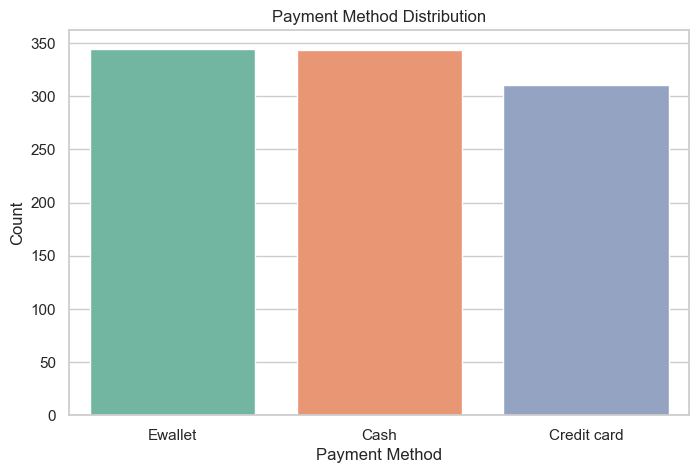

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='payment_method', palette='Set2')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [14]:
print(df['payment_method'].unique())
df['payment_method'].value_counts()

<StringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str


payment_method
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\2744608026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_method', palette='Set2')


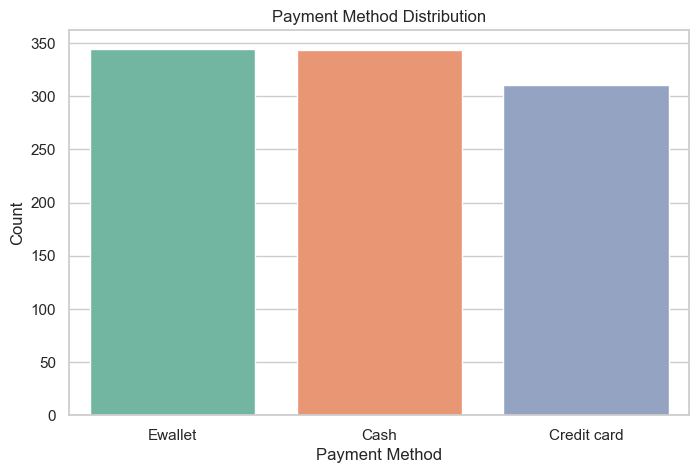

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='payment_method', palette='Set2')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\3874238450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_sales.index, y=branch_sales.values, palette='viridis')


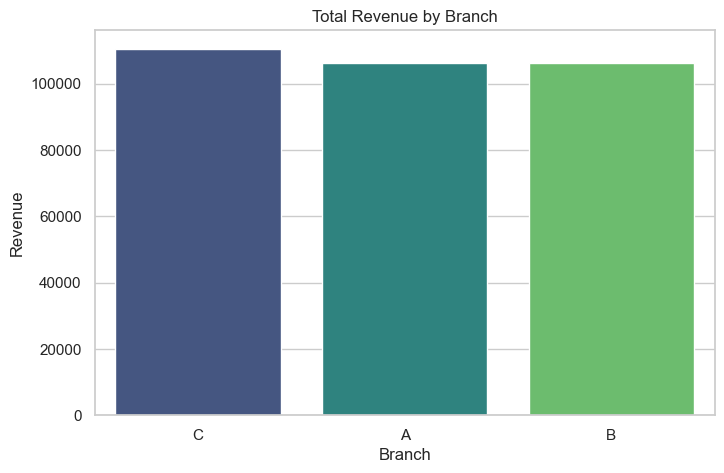

In [16]:
branch_sales = df.groupby('branch')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=branch_sales.index, y=branch_sales.values, palette='viridis')
plt.title('Total Revenue by Branch')
plt.xlabel('Branch')
plt.ylabel('Revenue')
plt.show()

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\1973412973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.values, y=product_sales.index, palette='magma')


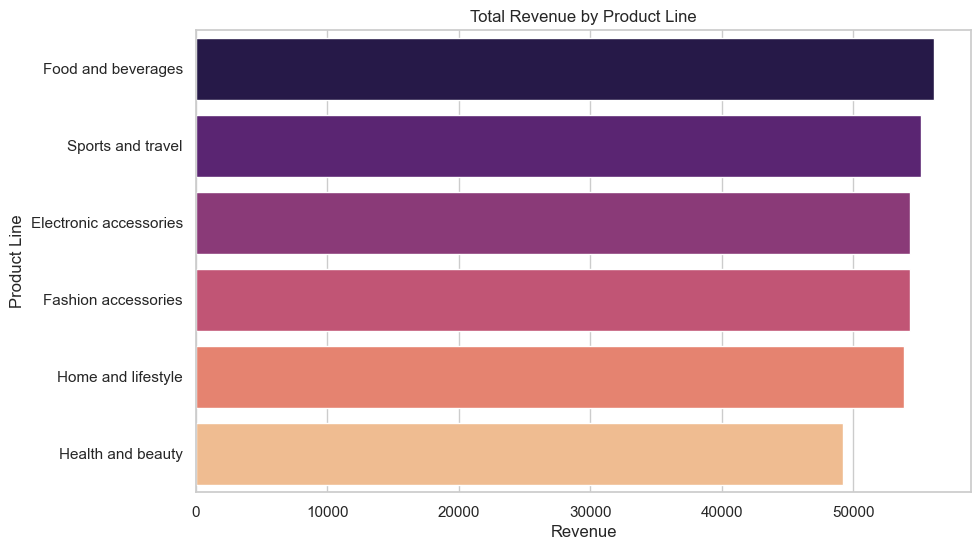

In [17]:
product_sales = df.groupby('product_line')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=product_sales.values, y=product_sales.index, palette='magma')
plt.title('Total Revenue by Product Line')
plt.xlabel('Revenue')
plt.ylabel('Product Line')
plt.show()

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\1533862831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='pastel')


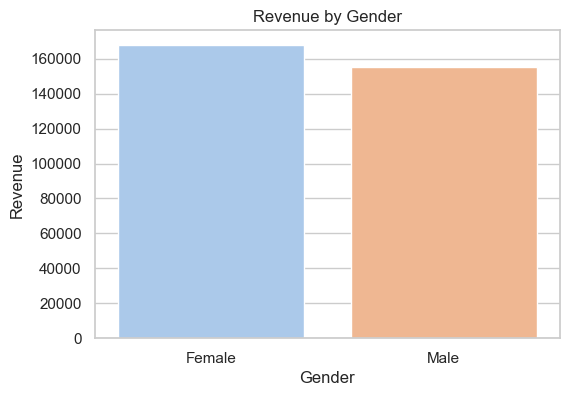

In [18]:
gender_sales = df.groupby('gender_customer')['revenue'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='pastel')
plt.title('Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Revenue')
plt.show()

C:\Users\Shravani\AppData\Local\Temp\ipykernel_13324\4232343014.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_sales.index, y=day_sales.values, palette='crest')


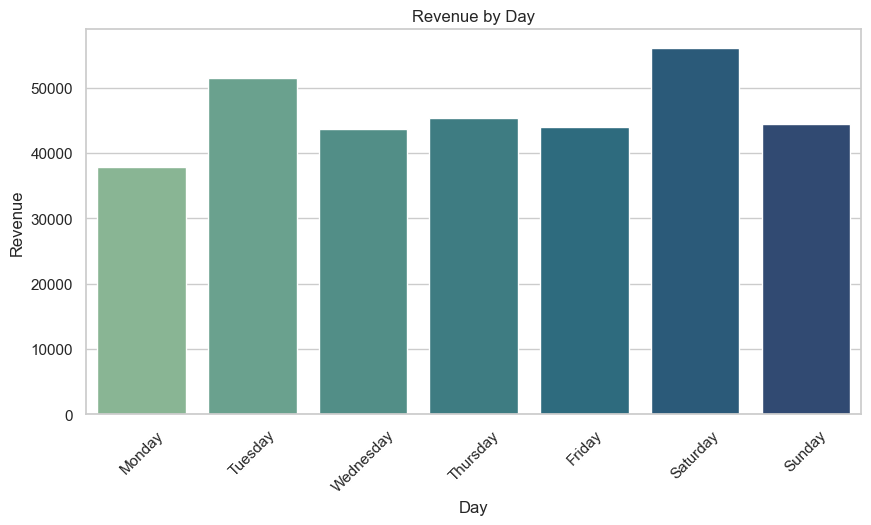

In [19]:
day_sales = df.groupby('day')['revenue'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(10,5))
sns.barplot(x=day_sales.index, y=day_sales.values, palette='crest')
plt.title('Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()